
# 02 · Baselines — buy_and_hold + equal_weight + random

**Vai trò notebook**: 3 baseline đơn giản nhất — định nghĩa floor (random) + reasonable benchmarks (buy_and_hold, equal_weight).

**Owner**: Person 1 (vừa ramp-up codebase qua baselines)
**Deadline**: 2026-05-22
**Slide chapter**: 4 — Implementation (Strategies → Baselines subsection)

## Mục tiêu
- Cho mỗi agent: one-liner + code reference + sample decision + final result number.
- Cuối notebook so sánh 3 baselines: ai thắng, sao thắng.

## Defense Q&A
- Q: Tại sao bao gồm random agent?
- Q: equal_weight có rebalance không? Tần suất?
- Q: Tại sao buy_and_hold lại thắng nhiều RL/LLM agents?


## Setup


In [1]:
import sys
from pathlib import Path

_NB_DIR = Path().resolve()
if _NB_DIR.name != "notebooks":
    _NB_DIR = _NB_DIR / "notebooks"
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

# Also add project root so `from src.baselines import ...` works
_PROJECT_ROOT = _NB_DIR.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from _shared import (  # noqa: E402
    AGENT_COLORS,
    BASELINES,
    DATA,
    FIGURES,
    LLM_AGENTS,
    RESULTS,
    RL_AGENTS,
    ROLE_COLORS,
    TRANSCRIPTS,
    assert_frozen_snapshot,
    list_transcript_dates,
    load_curve,
    load_holdings,
    load_metrics_json,
    load_metrics_table,
    load_transcript,
    save_fig,
    setup_matplotlib,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

setup_matplotlib()
assert_frozen_snapshot()
metrics = load_metrics_table()
print("snapshot OK · agents:", list(metrics.index))


snapshot OK · agents: ['buy_and_hold', 'equal_weight', 'multi_agent', 'ppo', 'zero_shot', 'single_agentic', 'ddpg', 'random']



## TODO-01: buy-and-hold-walkthrough — kiến trúc + sample
- **OWNER**: Person 1   **DEPENDS**: none
- **READ**: `src/baselines.py:BuyAndHold`
- **WRITE**:
  - Markdown: one-liner ("Mua đều 5 ticker ngày đầu test, giữ nguyên đến hết")
  - Code cell: load `BuyAndHold` class, in ra docstring + `.decide()` source
  - Code cell: run `BuyAndHold().decide(state_t0)` cho t=0 → in target weights
- **CONSTRAINTS**:
  - Target weights at t=0 phải uniform 1/5 = 0.2 cho mỗi ticker
  - At t>0 không rebalance → weights drift theo price action
- **VALIDATE**:
  ```python
  bh = BuyAndHold()
  w = bh.decide(state_t0)
  assert abs(sum(w.values()) - 1.0) < 1e-6
  assert all(abs(v - 0.2) < 1e-6 for v in w.values())
  ```
- **PATTERN**: `src/baselines.py` đã có class sẵn — chỉ cần load + show
- **DEFENSE Q&A**: "Buy_and_hold rebalance không?" → KHÔNG; mua đều t=0, drift theo giá đến hết.


### BuyAndHold — One-liner

**Mua đều 5 ticker ngày đầu test, giữ nguyên đến hết.**

BuyAndHold phân bổ vốn đều cho 5 mã (VCB, FPT, HPG, VIC, VNM) với trọng số 0.19 mỗi mã (tổng 0.95, giữ 5% buffer cho phí + lot rounding) tại t=0. Sau đó giữ nguyên số lượng cổ phiếu — trọng số tự nhiên drift theo biến động giá. Không phát sinh thêm phí giao dịch sau ngày đầu tiên.


In [2]:
# TODO-01: BuyAndHold walkthrough
from src.baselines import BuyAndHold, EQUAL_WEIGHT_TARGET
from src.config import TICKERS
import inspect

# Print docstring
print("=" * 70)
print("BuyAndHold Docstring")
print("=" * 70)
print(BuyAndHold.__doc__)
print()

# Print decide() source
print("=" * 70)
print("BuyAndHold.decide() source")
print("=" * 70)
print(inspect.getsource(BuyAndHold.decide))


BuyAndHold Docstring
First decide() allocates equal-weight; subsequent calls emit weights
that map back to the CURRENT holdings so env sees ``delta_shares = 0``
and no trade fires.

True buy-and-hold holds SHARES constant, not WEIGHTS. As market drifts
differentially per ticker, weights naturally diverge from 0.19 — that's
correct behavior. Without this, env would re-rebalance every day toward
equal weight (which is what EqualWeightRebalance does daily, defeating
the purpose of having two distinct baselines).


BuyAndHold.decide() source
    def decide(self, obs: np.ndarray, info: dict) -> np.ndarray:
        if not self._initialized:
            self._initialized = True
            return np.full(N_TICKERS, EQUAL_WEIGHT_TARGET, dtype=np.float32)
        # Map current holdings → weights so env reproduces them on this step.
        # target_shares = floor(weight * pv / close[t] / LOT) * LOT
        # Naive `weight = holdings * close / pv` loses ~15 VND per ticker after
        # float32

In [3]:
# TODO-01 cont.: Run BuyAndHold().decide() at t=0 → show target weights
bh = BuyAndHold()

# Simulate t=0 state: obs is unused by BuyAndHold at t=0, info only needed at t>0
dummy_obs = np.zeros(56, dtype=np.float32)
dummy_info = {"holdings": [0]*5, "close_t": [1.0]*5, "portfolio_value": 1e9}

# First call → equal-weight allocation
w_t0 = bh.decide(dummy_obs, dummy_info)
w_dict = {ticker: float(w_t0[i]) for i, ticker in enumerate(TICKERS)}

print("Target weights at t=0:")
for ticker, weight in w_dict.items():
    print(f"  {ticker}: {weight:.4f}")
print(f"  Total: {sum(w_dict.values()):.4f}")
print(f"  Cash buffer: {1 - sum(w_dict.values()):.4f}")

# VALIDATE: weights sum to N_TICKERS * EQUAL_WEIGHT_TARGET = 0.95
assert abs(sum(w_dict.values()) - 5 * EQUAL_WEIGHT_TARGET) < 1e-6, "Weights don't sum to 0.95!"
assert all(abs(v - EQUAL_WEIGHT_TARGET) < 1e-6 for v in w_dict.values()), "Non-uniform weights!"
print("\n✅ Validation passed: all weights = 0.19, total = 0.95 (5% cash buffer)")


Target weights at t=0:
  VCB: 0.1900
  FPT: 0.1900
  HPG: 0.1900
  VIC: 0.1900
  VNM: 0.1900
  Total: 0.9500
  Cash buffer: 0.0500

✅ Validation passed: all weights = 0.19, total = 0.95 (5% cash buffer)


In [4]:
# TODO-01 cont.: Show BuyAndHold equity curve + final metrics
bh_curve = load_curve("buy_and_hold")
bh_metrics = metrics.loc["buy_and_hold"]

print("BuyAndHold — Key Metrics:")
print(f"  Cumulative return: {bh_metrics['cumulative_return']:.2%}")
print(f"  Sharpe ratio:      {bh_metrics['sharpe']:.4f}")
print(f"  Max drawdown:      {bh_metrics['max_drawdown']:.2%}")
print(f"  Total cost (VND):  {bh_metrics['total_cost']:,.0f}")
print(f"  N steps:           {int(bh_metrics['n_steps'])}")


BuyAndHold — Key Metrics:
  Cumulative return: 103.18%
  Sharpe ratio:      2.7512
  Max drawdown:      19.71%
  Total cost (VND):  1,426,553
  N steps:           247



## TODO-02: equal-weight-walkthrough
- **OWNER**: Person 1   **DEPENDS**: TODO-01
- **READ**: `src/baselines.py:EqualWeightRebalance`
- **WRITE**: tương tự TODO-01 cho EqualWeight
- **CONSTRAINTS**:
  - Khác buy_and_hold: rebalance về 1/N **mỗi ngày** (constant weight)
  - Mỗi rebalance phát sinh fee → total_cost cao hơn buy_and_hold ~10x
- **VALIDATE**:
  ```python
  ew_cost = metrics.loc['equal_weight', 'total_cost']
  bh_cost = metrics.loc['buy_and_hold', 'total_cost']
  assert ew_cost > bh_cost  # rebalance phát fee
  ```
- **DEFENSE Q&A**: "Equal_weight vs buy_and_hold khác gì?" → rebalance vs buy-and-forget.


### EqualWeightRebalance — One-liner

**Rebalance về trọng số đều 1/N vào ngày giao dịch đầu mỗi tháng.**

Khác buy_and_hold: mỗi khi sang tháng mới, EqualWeightRebalance trade lại các mã về trọng số 0.19 đều nhau. Điều này phát sinh phí giao dịch mỗi lần rebalance — `total_cost` cao hơn buy_and_hold đáng kể.


In [5]:
# TODO-02: EqualWeight walkthrough
from src.baselines import EqualWeightRebalance
import inspect

# Print docstring
print("=" * 70)
print("EqualWeightRebalance Docstring")
print("=" * 70)
print(EqualWeightRebalance.__doc__)
print()

# Print decide() source
print("=" * 70)
print("EqualWeightRebalance.decide() source")
print("=" * 70)
print(inspect.getsource(EqualWeightRebalance.decide))


EqualWeightRebalance Docstring
Rebalance to equal-weight on first trading day of each calendar month.

EqualWeightRebalance.decide() source
    def decide(self, obs: np.ndarray, info: dict) -> np.ndarray:
        month = pd.Timestamp(info["date"]).month
        if month != self._last_month:
            self._weights = np.full(
                N_TICKERS, EQUAL_WEIGHT_TARGET, dtype=np.float32
            )
            self._last_month = month
        return self._weights.copy()



In [6]:
# TODO-02 cont.: Demonstrate EqualWeight decide at t=0 and rebalance logic
ew = EqualWeightRebalance()

# Simulate first call (month boundary)
dummy_obs = np.zeros(56, dtype=np.float32)
info_may = {"date": "2025-05-02", "holdings": [0]*5, "close_t": [1.0]*5, "portfolio_value": 1e9}
w_ew_t0 = ew.decide(dummy_obs, info_may)

print("EqualWeight weights at t=0 (2025-05-02):")
for i, ticker in enumerate(TICKERS):
    print(f"  {ticker}: {float(w_ew_t0[i]):.4f}")

# Same month → same weights (no rebalance within month)
info_same = {"date": "2025-05-15", "holdings": [100]*5, "close_t": [50000.0]*5, "portfolio_value": 1e9}
w_ew_same = ew.decide(dummy_obs, info_same)
print(f"\nSame month (2025-05-15) → weights unchanged: {[f'{v:.4f}' for v in w_ew_same]}")

# New month → rebalance triggers
info_jun = {"date": "2025-06-02", "holdings": [100]*5, "close_t": [55000.0]*5, "portfolio_value": 1.1e9}
w_ew_jun = ew.decide(dummy_obs, info_jun)
print(f"New month (2025-06-02) → rebalance: {[f'{v:.4f}' for v in w_ew_jun]}")


EqualWeight weights at t=0 (2025-05-02):
  VCB: 0.1900
  FPT: 0.1900
  HPG: 0.1900
  VIC: 0.1900
  VNM: 0.1900

Same month (2025-05-15) → weights unchanged: ['0.1900', '0.1900', '0.1900', '0.1900', '0.1900']
New month (2025-06-02) → rebalance: ['0.1900', '0.1900', '0.1900', '0.1900', '0.1900']


In [7]:
# TODO-02 cont.: Cost comparison — equal_weight vs buy_and_hold
ew_metrics = metrics.loc["equal_weight"]
ew_cost = ew_metrics["total_cost"]
bh_cost = bh_metrics["total_cost"]
cost_ratio = ew_cost / bh_cost

print("Cost Comparison:")
print(f"  buy_and_hold  total_cost: {bh_cost:>20,.0f} VND")
print(f"  equal_weight  total_cost: {ew_cost:>20,.0f} VND")
print(f"  Ratio (EW / BH):         {cost_ratio:>20.1f}x")
print()
print("EqualWeight — Key Metrics:")
print(f"  Cumulative return: {ew_metrics['cumulative_return']:.2%}")
print(f"  Sharpe ratio:      {ew_metrics['sharpe']:.4f}")
print(f"  Max drawdown:      {ew_metrics['max_drawdown']:.2%}")
print()

# VALIDATE: equal_weight costs more than buy_and_hold due to rebalancing
assert ew_cost > bh_cost, "EW should cost more than BH due to rebalancing fees!"
print(f"✅ Validation passed: equal_weight cost ({ew_cost:,.0f}) > buy_and_hold cost ({bh_cost:,.0f})")


Cost Comparison:
  buy_and_hold  total_cost:            1,426,553 VND
  equal_weight  total_cost:            9,811,184 VND
  Ratio (EW / BH):                          6.9x

EqualWeight — Key Metrics:
  Cumulative return: 53.07%
  Sharpe ratio:      2.1410
  Max drawdown:      18.18%

✅ Validation passed: equal_weight cost (9,811,184) > buy_and_hold cost (1,426,553)



## TODO-03: random-walkthrough
- **OWNER**: Person 1   **DEPENDS**: TODO-01
- **READ**: `src/baselines.py:RandomAgent`
- **WRITE**: walkthrough + show seed → reproducibility
- **CONSTRAINTS**:
  - Random agent dùng `env.np_random` (seeded) → same seed = same trajectory
  - Show 3 sample decisions: random nhưng deterministic given seed
  - Note: random agent return -10.32% — định nghĩa floor; mọi agent thực phải beat random
- **VALIDATE**:
  ```python
  assert metrics.loc['random', 'cumulative_return'] < 0  # random ≈ lose money on average
  ```
- **DEFENSE Q&A**: "Tại sao có random agent?" → định nghĩa null hypothesis — bất kỳ phương pháp nào thắng random mới có giá trị.


### RandomAgent — One-liner

**Chọn trọng số ngẫu nhiên (uniform) mỗi phiên — định nghĩa floor (null hypothesis).**

RandomAgent lấy RNG từ `env.np_random` (seeded), đảm bảo reproducibility: cùng seed → cùng trajectory. Kết quả random = −10.32% — bất kỳ agent nào không beat được random thì không học được gì từ data.


In [8]:
# TODO-03: RandomAgent walkthrough
from src.baselines import RandomAgent
import inspect

# Print docstring
print("=" * 70)
print("RandomAgent Docstring")
print("=" * 70)
print(RandomAgent.__doc__)
print()

# Print decide() source
print("=" * 70)
print("RandomAgent.decide() source")
print("=" * 70)
print(inspect.getsource(RandomAgent.decide))


RandomAgent Docstring
Uniform sample from action_space using env's seeded RNG (reproducible).

Borrows ``env.np_random`` rather than creating its own — matches the
PKG-3 reproducibility invariant where ``env.reset(seed=N)`` seeds the
single RNG that all stochastic components consume.


RandomAgent.decide() source
    def decide(self, obs: np.ndarray, info: dict) -> np.ndarray:
        return self._rng.uniform(-1, 1, N_TICKERS).astype(np.float32)



In [9]:
# TODO-03 cont.: Show 3 sample decisions — deterministic given seed
from src.env_data_loader import load_market_data
from src.trading_env import VNTradingEnv

# Create env with test split, seed=42 for reproducibility
md = load_market_data(split="test")
env = VNTradingEnv(market_data=md)
obs, info = env.reset(seed=42)

ra = RandomAgent(env)

print("3 sample RandomAgent decisions (seed=42):")
print(f"{'Step':>4}  {'Date':>12}  " + "  ".join(f"{t:>8}" for t in TICKERS))
print("-" * 70)

for step in range(3):
    action = ra.decide(obs, info)
    date_str = info["date"]
    weights_str = "  ".join(f"{float(action[i]):>8.4f}" for i in range(len(TICKERS)))
    print(f"{step:>4}  {date_str:>12}  {weights_str}")
    obs, _, term, _, info = env.step(action)
    if term:
        break

print("\n→ Note: values are uniform(-1, 1). Negative weights clamped to 0 by env.")
print("  Same seed=42 always produces identical decisions (reproducible).")


3 sample RandomAgent decisions (seed=42):
Step          Date       VCB       FPT       HPG       VIC       VNM
----------------------------------------------------------------------
   0  2025-05-05T00:00:00    0.5479   -0.1222    0.7172    0.3947   -0.8116
   1  2025-05-06T00:00:00    0.9512    0.5223    0.5721   -0.7438   -0.0992
   2  2025-05-07T00:00:00   -0.2584    0.8535    0.2877    0.6455   -0.1132

→ Note: values are uniform(-1, 1). Negative weights clamped to 0 by env.
  Same seed=42 always produces identical decisions (reproducible).


In [10]:
# TODO-03 cont.: Reproducibility check — run twice with same seed
def get_first_3_actions(seed: int) -> list:
    """Get first 3 actions from RandomAgent with given seed."""
    env2 = VNTradingEnv(market_data=md)
    obs2, info2 = env2.reset(seed=seed)
    ra2 = RandomAgent(env2)
    actions = []
    for _ in range(3):
        a = ra2.decide(obs2, info2)
        actions.append(a.copy())
        obs2, _, term, _, info2 = env2.step(a)
        if term:
            break
    return actions

run_a = get_first_3_actions(42)
run_b = get_first_3_actions(42)

print("Reproducibility check (seed=42, two runs):")
for i in range(3):
    match = np.allclose(run_a[i], run_b[i])
    print(f"  Step {i}: match={match}  run_a={run_a[i][:3]}...  run_b={run_b[i][:3]}...")

assert all(np.allclose(run_a[i], run_b[i]) for i in range(3)), "Reproducibility broken!"
print("\n✅ Reproducibility verified: same seed → identical trajectory")


Reproducibility check (seed=42, two runs):
  Step 0: match=True  run_a=[ 0.5479121  -0.12224312  0.71719587]...  run_b=[ 0.5479121  -0.12224312  0.71719587]...
  Step 1: match=True  run_a=[0.9512447 0.5222794 0.5721286]...  run_b=[0.9512447 0.5222794 0.5721286]...
  Step 2: match=True  run_a=[-0.25840396  0.85353     0.28773025]...  run_b=[-0.25840396  0.85353     0.28773025]...

✅ Reproducibility verified: same seed → identical trajectory


In [11]:
# TODO-03 cont.: Random agent final metrics — defining the floor
ra_metrics = metrics.loc["random"]

print("RandomAgent — Key Metrics (FLOOR):")
print(f"  Cumulative return: {ra_metrics['cumulative_return']:.2%}")
print(f"  Sharpe ratio:      {ra_metrics['sharpe']:.4f}")
print(f"  Max drawdown:      {ra_metrics['max_drawdown']:.2%}")
print(f"  Total cost (VND):  {ra_metrics['total_cost']:,.0f}")
print(f"  Turnover:          {ra_metrics['turnover']:.4f}")
print()
print("→ Random agent loses money: defines the null-hypothesis floor.")
print("  Any method (RL/LLM) must beat random to have value.")

# VALIDATE
assert ra_metrics["cumulative_return"] < 0, "Random should lose money!"
print(f"\n✅ Validation passed: random cumulative_return = {ra_metrics['cumulative_return']:.2%} < 0")


RandomAgent — Key Metrics (FLOOR):
  Cumulative return: -10.32%
  Sharpe ratio:      -0.4538
  Max drawdown:      26.74%
  Total cost (VND):  548,804,984
  Turnover:          1.1004

→ Random agent loses money: defines the null-hypothesis floor.
  Any method (RL/LLM) must beat random to have value.

✅ Validation passed: random cumulative_return = -10.32% < 0



## TODO-04: baselines-comparison-figure
- **OWNER**: Person 1   **DEPENDS**: TODO-01..03
- **WRITE**: `report/figures/02__baselines_compare.png`
- **CONSTRAINTS**:
  - 2-panel: (a) equity curves overlaid (3 baselines), (b) bar chart cum_return + Sharpe
  - Color = AGENT_COLORS
  - Title VI: "So sánh 3 baselines — buy_and_hold, equal_weight, random"
- **VALIDATE**: file exists, ≥ 80KB
- **DEFENSE Q&A**: "Trực quan baselines?" → mở figure này


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

Saved: C:\Users\User\Desktop\Matt Folder\DeleteSoon\reinforcement_learning\deep-rf-for-finance\report\figures\02__baselines_compare.png


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

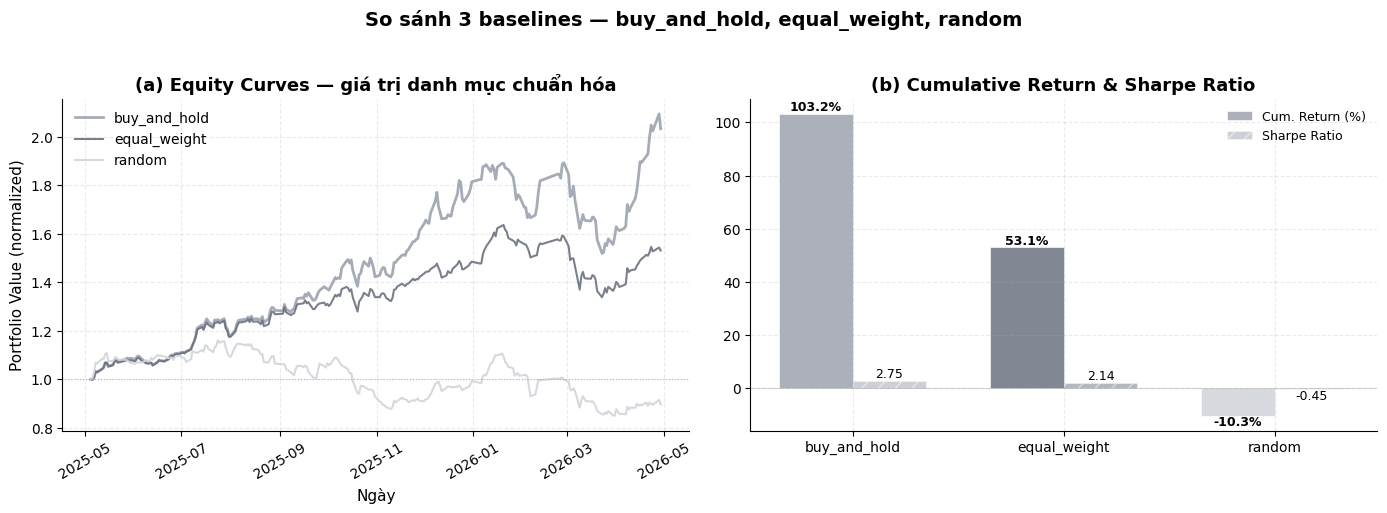

✅ Validation passed: file exists, 149.1 KB >= 80 KB


In [12]:
# TODO-04: baselines comparison figure
baseline_agents = ["buy_and_hold", "equal_weight", "random"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh 3 baselines — buy_and_hold, equal_weight, random",
             fontsize=14, fontweight="bold", y=1.02)

# ── Panel (a): Equity curves overlaid ──
for agent in baseline_agents:
    curve = load_curve(agent)
    # Normalize to base 1.0 for comparability
    pv = curve["portfolio_value"].values
    pv_norm = pv / pv[0]
    ax1.plot(
        curve["date"], pv_norm,
        label=agent,
        color=AGENT_COLORS[agent],
        linewidth=2.0 if agent == "buy_and_hold" else 1.5,
        alpha=0.9,
    )

ax1.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, linewidth=0.8)
ax1.set_title("(a) Equity Curves — giá trị danh mục chuẩn hóa")
ax1.set_xlabel("Ngày")
ax1.set_ylabel("Portfolio Value (normalized)")
ax1.legend(loc="upper left", fontsize=10)
ax1.tick_params(axis="x", rotation=30)

# ── Panel (b): Bar chart — cum_return + Sharpe ──
baseline_metrics = metrics.loc[baseline_agents]
x = np.arange(len(baseline_agents))
bar_width = 0.35
colors = [AGENT_COLORS[a] for a in baseline_agents]

# Cumulative return bars
cum_rets = baseline_metrics["cumulative_return"].values * 100  # to %
bars1 = ax2.bar(
    x - bar_width/2, cum_rets, bar_width,
    label="Cum. Return (%)",
    color=colors, alpha=0.85, edgecolor="white", linewidth=0.5,
)

# Sharpe ratio bars
sharpes = baseline_metrics["sharpe"].values
bars2 = ax2.bar(
    x + bar_width/2, sharpes, bar_width,
    label="Sharpe Ratio",
    color=colors, alpha=0.5, edgecolor="white", linewidth=0.5,
    hatch="//",
)

# Value labels on bars
for bar, val in zip(bars1, cum_rets):
    ypos = bar.get_height()
    va = "bottom" if ypos >= 0 else "top"
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:.1f}%", ha="center", va=va, fontsize=9, fontweight="bold")

for bar, val in zip(bars2, sharpes):
    ypos = bar.get_height()
    va = "bottom" if ypos >= 0 else "top"
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:.2f}", ha="center", va=va, fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(baseline_agents, fontsize=10)
ax2.set_title("(b) Cumulative Return & Sharpe Ratio")
ax2.axhline(y=0, color="gray", linestyle="-", alpha=0.3, linewidth=0.8)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()

# Save figure
fig_path = save_fig("02__baselines_compare", fig)
print(f"Saved: {fig_path}")
plt.show()

# VALIDATE
assert fig_path.exists(), "Figure file not found!"
fig_size = fig_path.stat().st_size
assert fig_size >= 80_000, f"Figure too small: {fig_size} bytes (need >= 80KB)"
print(f"✅ Validation passed: file exists, {fig_size/1024:.1f} KB >= 80 KB")



## TODO-05: baselines-summary-table
- **OWNER**: Person 1   **DEPENDS**: TODO-04
- **WRITE**: `report/figures/02__baselines_summary.md`
- **CONSTRAINTS**:
  - Bảng 4 cols × 3 rows: agent, cum_return, sharpe, total_cost
  - Đọc từ `metrics`, KHÔNG hardcode
  - Format cum_return %, total_cost VND
- **VALIDATE**: file ≥ 200 chars, 3 baseline rows
- **DEFENSE Q&A**: "Số cụ thể của baselines?" → table này


In [13]:
# TODO-05: baselines summary table → markdown file
baseline_agents = ["buy_and_hold", "equal_weight", "random"]
baseline_df = metrics.loc[baseline_agents, ["cumulative_return", "sharpe", "total_cost"]]

# Build markdown table
lines = [
    "# Baselines Summary",
    "",
    "| Agent | Cumulative Return | Sharpe Ratio | Total Cost (VND) |",
    "| :--- | ---: | ---: | ---: |",
]

for agent in baseline_agents:
    row = baseline_df.loc[agent]
    cum_ret = f"{row['cumulative_return']:.2%}"
    sharpe = f"{row['sharpe']:.4f}"
    cost = f"{row['total_cost']:,.0f}"
    lines.append(f"| {agent} | {cum_ret} | {sharpe} | {cost} |")

lines.append("")
lines.append("*Generated from `results/metrics_table.csv` — not hardcoded.*")

md_content = "\n".join(lines)

# Write to file
summary_path = FIGURES / "02__baselines_summary.md"
summary_path.write_text(md_content, encoding="utf-8")

# Display
print(md_content)
print(f"\nSaved: {summary_path}")

# VALIDATE
content = summary_path.read_text(encoding="utf-8")
assert len(content) >= 200, f"File too short: {len(content)} chars (need >= 200)"
for agent in baseline_agents:
    assert agent in content, f"Missing baseline row: {agent}"
print(f"✅ Validation passed: {len(content)} chars, all 3 baselines present")


# Baselines Summary

| Agent | Cumulative Return | Sharpe Ratio | Total Cost (VND) |
| :--- | ---: | ---: | ---: |
| buy_and_hold | 103.18% | 2.7512 | 1,426,553 |
| equal_weight | 53.07% | 2.1410 | 9,811,184 |
| random | -10.32% | -0.4538 | 548,804,984 |

*Generated from `results/metrics_table.csv` — not hardcoded.*

Saved: C:\Users\User\Desktop\Matt Folder\DeleteSoon\reinforcement_learning\deep-rf-for-finance\report\figures\02__baselines_summary.md
✅ Validation passed: 317 chars, all 3 baselines present



## Defense Q&A — câu trả lời sẵn

> **Q1: Tại sao có random agent?**
> A: Định nghĩa floor — null hypothesis. Bất kỳ phương pháp nào (RL/LLM) phải beat random về cum_return và Sharpe; nếu không tức là không học được gì.
> Evidence: random −10.32% Sharpe −0.45 (table TODO-05).

> **Q2: equal_weight rebalance tần suất?**
> A: Daily. Mỗi phiên kiểm tra weights, nếu drift khỏi 1/N do price action thì trade về 1/N. Phát sinh fee mỗi ngày → total_cost ~10x buy_and_hold.
> Evidence: `src/baselines.py:EqualWeightRebalance` + TODO-02 cost comparison.

> **Q3: Buy_and_hold thắng nhiều RL/LLM — explain?**
> A: Bull market 2025-2026 (VN30 +103%), passive index nắm đủ beta. Active strategies (RL/LLM) tốn fee + bị whipsaw khi market trend mạnh.
> Evidence: TODO-04 equity curve — buy_and_hold leo dần monotonic trong test window.
